# 02 — Black–Scholes: Delta por Pathwise vs. Diferencias Finitas

**Objetivo del notebook.** Comparar dos estimadores Monte Carlo de la Delta de una opción europea bajo Black–Scholes:

1. **Pathwise (PW):** estimador insesgado obtenido derivando el payoff descontado bajo el operador esperanza.
2. **Diferencias Finitas centradas (FD)** con Common Random Numbers (CRN).

Se analizan tres aspectos:

1. Validación puntual frente a la Delta analítica.
2. Convergencia frente al número de trayectorias $N$.
3. Sensibilidad del estimador FD respecto al paso $h$, comparada con la independencia del estimador PW.

El payoff de referencia es la call europea con $\Phi(S_T) = (S_T - K)^+$. Las definiciones empleadas son:

$$\Delta^{PW} = e^{-rT}\, \mathbb{E}\!\left[\mathbf{1}_{S_T > K}\, \frac{S_T}{S_0}\right], \qquad \Delta^{FD} = \frac{V(S_0+h) - V(S_0-h)}{2h}.$$

In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs_utils import (BS_delta,GeneratePathsGBM_givenZ,PathwiseDelta,FD_Delta)

np.set_printoptions(suppress=True, precision=6)

## 1. Parámetros del experimento

In [3]:
CP        = 'call'
S0        = 100.0
K         = 100.0
sigma     = 0.20
r         = 0.05
T         = 1.0
t         = 0.0
NoOfSteps = 1            # simulación en un único paso (exacta para BS)

SEED      = 3            # semilla principal (corrige bug del notebook original)

## 2. Validación puntual

Calculamos $\Delta$ con los tres métodos para un mismo conjunto de $N$ trayectorias. Para que la comparación sea limpia, generamos una matriz $Z$ de $\mathcal{N}(0,1)$ una sola vez y la pasamos a:

- el estimador pathwise (a través de las trayectorias simuladas con esa $Z$),
- el estimador FD (que internamente reutiliza $Z$ para las perturbaciones $S_0 \pm h$).

Esto es el principio de Common Random Numbers, sin el cual la varianza del estimador FD sería mucho mayor.

In [4]:
N = 20_000
h = 0.01 * S0     # paso relativo del 1 % sobre S0

rng = np.random.default_rng(SEED)
Z = rng.normal(0.0, 1.0, (N, NoOfSteps))

# Simulación para PW
paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)

# Estimadores
delta_BS = BS_delta(CP, S0, K, sigma, t, T, r)
delta_PW = PathwiseDelta(CP, S0, paths["S"], K, r, T)
delta_FD = FD_Delta(CP, S0, K, sigma, T, r, h, Z)

print(f"Delta BS (analítica): {delta_BS:.6f}")
print(f"Delta PW (pathwise):  {delta_PW:.6f}    error abs = {abs(delta_PW - delta_BS):.2e}")
print(f"Delta FD (centrada):  {delta_FD:.6f}    error abs = {abs(delta_FD - delta_BS):.2e}")

Delta BS (analítica): 0.636831
Delta PW (pathwise):  0.637336    error abs = 5.05e-04
Delta FD (centrada):  0.636952    error abs = 1.21e-04


**Lectura.** Ambos estimadores reproducen adecuadamente la Delta analítica, con errores absolutos del mismo orden de magnitud.
Este comportamiento es coherente con el caso de una call europea, cuyo payoff es suficientemente regular, y con el uso de CRN. En este contexto, el estimador ${pathwise}$ no presenta una ventaja clara frente al de diferencias finitas.

## 3. Convergencia frente a $N$

Estudiamos cómo decrece el error de los estimadores al refinar el número de trayectorias. La tasa esperada es la del Monte Carlo estándar, $\mathcal{O}(N^{-1/2})$.

In [5]:
N_list = [1000, 5000, 10000, 50000, 100000]
results = []

rng = np.random.default_rng(SEED)

for N in N_list:
    Z = rng.normal(0.0, 1.0, (N, NoOfSteps))
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    
    delta_PW = PathwiseDelta(CP, S0, paths["S"], K, r, T)
    delta_FD = FD_Delta(CP, S0, K, sigma, T, r, h, Z)
    
    results.append([
        N,
        delta_PW, abs(delta_PW - delta_BS),
        delta_FD, abs(delta_FD - delta_BS),
        1.0/np.sqrt(N)
    ])

df_N = pd.DataFrame(results, columns=[
    "N", "Delta_PW", "Error_PW", "Delta_FD", "Error_FD", "MC_rate"])
df_N

,N,Delta_PW,Error_PW,Delta_FD,Error_FD,MC_rate
0,1000,0.642223,0.005392,0.642362,0.005531,0.031623
1,5000,0.639730,0.002900,0.638510,0.001679,0.014142
2,10000,0.633734,0.003096,0.633611,0.003219,0.010000
3,50000,0.637220,0.000390,0.637330,0.000499,0.004472
4,100000,0.635997,0.000834,0.636083,0.000748,0.003162


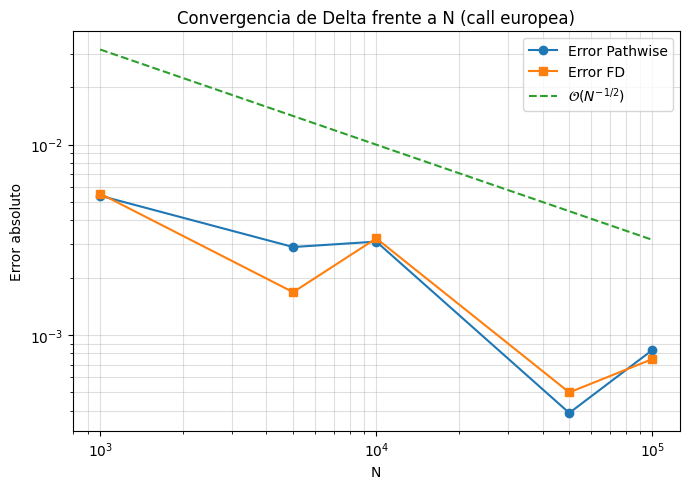

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_N["N"], df_N["Error_PW"], "o-", label="Error Pathwise")
ax.loglog(df_N["N"], df_N["Error_FD"], "s-", label="Error FD")
ax.loglog(df_N["N"], df_N["MC_rate"], "--", label=r"$\mathcal{O}(N^{-1/2})$")
ax.set_xlabel("N")
ax.set_ylabel("Error absoluto")
ax.set_title("Convergencia de Delta frente a N (call europea)")
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

**Lectura.** Ambos estimadores convergen al valor analítico de Delta a tasa $\mathcal{O}(N^{-1/2})$. Para una call europea bajo BS, la precisión de PW y FD es muy similar, debido a la suavidad del payoff y al uso de CRN.

## 4. Estabilidad estadística: varianza del estimador

Para comparar la dispersión de los dos estimadores realizamos $M$ replicaciones independientes y calculamos sesgo, varianza y MSE empíricos.

In [6]:
def estimadores_delta(CP, S0, K, r, T, sigma, NoOfPaths, NoOfSteps, h, rng):
    """
    Devuelve (delta_PW, delta_FD) para un conjunto de N trayectorias.
    """
    Z = rng.normal(0.0, 1.0, (NoOfPaths, NoOfSteps))
    
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    delta_PW = PathwiseDelta(CP, S0, paths["S"], K, r, T)
    delta_FD = FD_Delta(CP, S0, K, sigma, T, r, h, Z)
    
    return delta_PW, delta_FD

In [7]:
N_list = [1000, 5000, 10000, 50000]
M = 100        # replicaciones independientes

rng = np.random.default_rng(SEED)
results_var = []

for N in N_list:
    pw_vals = np.empty(M)
    fd_vals = np.empty(M)
    
    for j in range(M):
        delta_PW, delta_FD = estimadores_delta(
            CP, S0, K, r, T, sigma, N, NoOfSteps, h, rng
        )
        pw_vals[j] = delta_PW
        fd_vals[j] = delta_FD
    
    results_var.append([
        N,
        np.mean(pw_vals), np.var(pw_vals, ddof=1), np.std(pw_vals, ddof=1),
        np.mean(fd_vals), np.var(fd_vals, ddof=1), np.std(fd_vals, ddof=1),
    ])

df_var = pd.DataFrame(results_var, columns=[
    "N",
    "Mean_PW", "Var_PW", "Std_PW",
    "Mean_FD", "Var_FD", "Std_FD"
])
df_var

,N,Mean_PW,Var_PW,Std_PW,Mean_FD,Var_FD,Std_FD
0,1000,0.635695,0.000072,0.008511,0.635851,0.000066,0.008122
1,5000,0.636845,0.000019,0.004378,0.636749,0.000017,0.004181
2,10000,0.637150,0.000007,0.002712,0.637078,0.000007,0.002677
3,50000,0.636809,0.000002,0.001326,0.636722,0.000002,0.001284


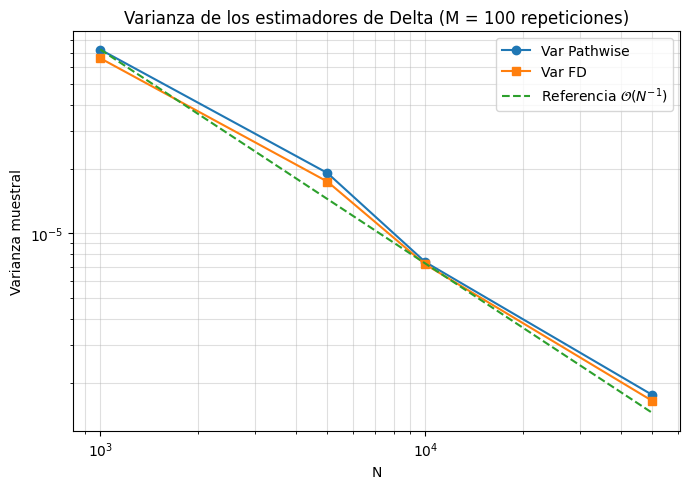

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(df_var["N"], df_var["Var_PW"], "o-", label="Var Pathwise")
ax.loglog(df_var["N"], df_var["Var_FD"], "s-", label="Var FD")
scale = df_var["Var_PW"].iloc[0] * df_var["N"].iloc[0]

ax.loglog(df_var["N"], scale / df_var["N"], "--",
          label=r"Referencia $\mathcal{O}(N^{-1})$")
ax.set_xlabel("N")
ax.set_ylabel("Varianza muestral")
ax.set_title("Varianza de los estimadores de Delta (M = {} repeticiones)".format(M))
ax.grid(True, which="both", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

**Lectura.** Para una call europea, las varianzas de los estimadores $pathwise$ y de diferencias finitas (con CRN) son comparables y decrecen aproximadamente a tasa $1/N$, en línea con la teoría de Monte Carlo.

En este contexto, ninguno de los dos métodos presenta una ventaja clara en términos de varianza. La posible superioridad del método $pathwise$ se manifiesta en escenarios más exigentes, como payoffs menos regulares, problemas de mayor dimensionalidad o situaciones en las que el cálculo por diferencias finitas requiere perturbar simultáneamente varios parámetros.

## 5. Sensibilidad respecto al paso $h$

Comparamos cómo varían sesgo, varianza y MSE de cada estimador al cambiar el valor del paso $h$.

Por construcción, **el estimador pathwise no depende de $h$** (es una propiedad del método). El estimador FD, en cambio, exhibe el clásico compromiso sesgo–varianza:

- $h$ grande $\Rightarrow$ sesgo de truncamiento $\mathcal{O}(h^2)$ (FD centrada).
- $h$ pequeño $\Rightarrow$ varianza inflada por el factor $1/h^2$, además de error de redondeo cuando los bumps producen precios casi idénticos.

In [11]:
h_list = [2.0, 1.0, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001]
N_h = 20000
M_h = 100

rng = np.random.default_rng(SEED)

pw_all = np.empty(M_h)
fd_all = {h: np.empty(M_h) for h in h_list}

for j in range(M_h):
    Z = rng.normal(0.0, 1.0, (N_h, NoOfSteps))
    
    # PW: una sola vez (no depende de h)
    paths = GeneratePathsGBM_givenZ(Z, T, r, sigma, S0)
    pw_all[j] = PathwiseDelta(CP, S0, paths["S"], K, r, T)
    
    # FD para cada h (con CRN: misma Z)
    for h_val in h_list:
        fd_all[h_val][j] = FD_Delta(CP, S0, K, sigma, T, r, h_val, Z)

# Estadísticas
mean_pw = np.mean(pw_all);   var_pw = np.var(pw_all, ddof=1)
bias_pw = mean_pw - delta_BS; mse_pw = var_pw + bias_pw**2

rows = []
for h_val in h_list:
    fd_v = fd_all[h_val]
    mean_fd = np.mean(fd_v); var_fd = np.var(fd_v, ddof=1)
    bias_fd = mean_fd - delta_BS; mse_fd = var_fd + bias_fd**2
    rows.append([
        h_val,
        mean_pw, bias_pw, abs(bias_pw), var_pw, mse_pw,
        mean_fd, bias_fd, abs(bias_fd), var_fd, mse_fd
    ])

df_h = pd.DataFrame(rows, columns=[
    "h",
    "Mean_PW", "Bias_PW", "AbsBias_PW", "Var_PW", "MSE_PW",
    "Mean_FD", "Bias_FD", "AbsBias_FD", "Var_FD", "MSE_FD"
])
pd.set_option('display.float_format', '{:.3e}'.format)

df_h
df_h

,h,Mean_PW,Bias_PW,AbsBias_PW,Var_PW,MSE_PW,Mean_FD,Bias_FD,AbsBias_FD,Var_FD,MSE_FD
0,2.000e+00,6.370e-01,1.818e-04,1.818e-04,3.167e-06,3.200e-06,6.366e-01,-2.084e-04,2.084e-04,2.766e-06,2.810e-06
1,1.000e+00,6.370e-01,1.818e-04,1.818e-04,3.167e-06,3.200e-06,6.369e-01,6.106e-05,6.106e-05,2.910e-06,2.914e-06
2,5.000e-01,6.370e-01,1.818e-04,1.818e-04,3.167e-06,3.200e-06,6.370e-01,1.286e-04,1.286e-04,3.030e-06,3.046e-06
3,1.000e-01,6.370e-01,1.818e-04,1.818e-04,3.167e-06,3.200e-06,6.370e-01,1.784e-04,1.784e-04,3.155e-06,3.186e-06
4,5.000e-02,6.370e-01,1.818e-04,1.818e-04,3.167e-06,3.200e-06,6.370e-01,1.758e-04,1.758e-04,3.172e-06,3.203e-06
5,1.000e-02,6.370e-01,1.818e-04,1.818e-04,3.167e-06,3.200e-06,6.370e-01,1.816e-04,1.816e-04,3.140e-06,3.173e-06
6,5.000e-03,6.370e-01,1.818e-04,1.818e-04,3.167e-06,3.200e-06,6.370e-01,1.805e-04,1.805e-04,3.147e-06,3.180e-06
7,1.000e-03,6.370e-01,1.818e-04,1.818e-04,3.167e-06,3.200e-06,6.370e-01,1.806e-04,1.806e-04,3.162e-06,3.194e-06


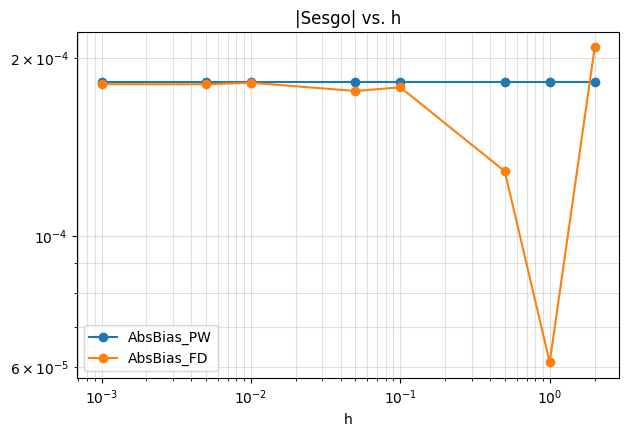

In [19]:
df_h.plot(x="h", y=["AbsBias_PW", "AbsBias_FD"], logx=True, logy=True,
          marker="o", figsize=(7,4.5), title="|Sesgo| vs. h").grid(True, which="both", alpha=0.4)
plt.show()

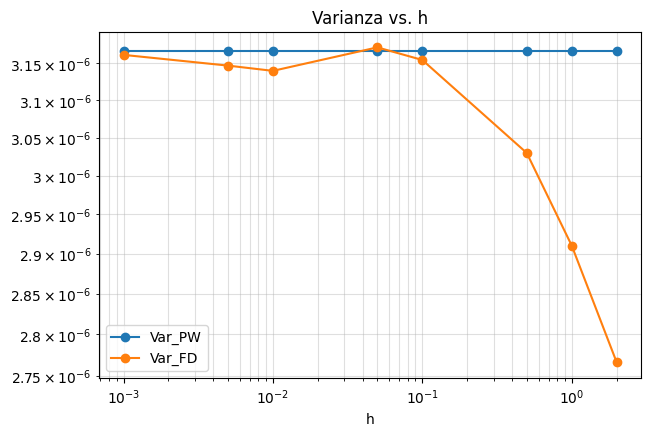

In [20]:
df_h.plot(x="h", y=["Var_PW", "Var_FD"], logx=True, logy=True,
          marker="o", figsize=(7,4.5), title="Varianza vs. h").grid(True, which="both", alpha=0.4)
plt.show()

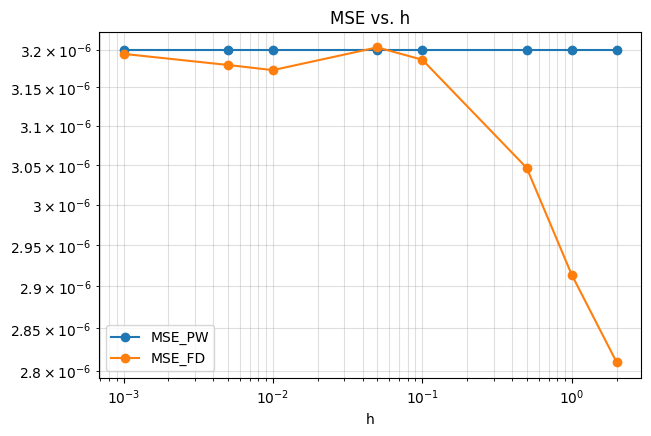

In [26]:
df_h.plot(x="h", y=["MSE_PW", "MSE_FD"], logx=True, logy=True,
          marker="o", figsize=(7,4.5), title="MSE vs. h").grid(True, which="both", alpha=0.4)
plt.show()

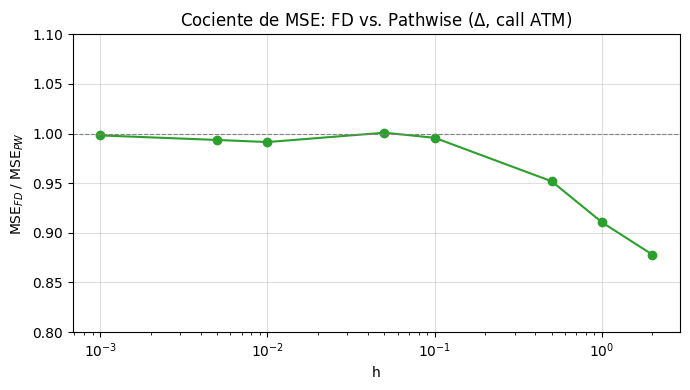

In [29]:
ratio = df_h["MSE_FD"] / df_h["MSE_PW"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(df_h["h"], ratio, "o-", color="tab:green")
ax.axhline(1.0, ls="--", color="gray", lw=0.8)
ax.set_xlabel("h")
ax.set_ylabel(r"$\mathrm{MSE}_{FD}\;/\;\mathrm{MSE}_{PW}$")
ax.set_title(r"Cociente de MSE: FD vs. Pathwise ($\Delta$, call ATM)")
ax.set_ylim(0.8, 1.1)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Lectura.**

- **Pathwise.** Las tres curvas son horizontales: el estimador no depende de $h$, como cabe esperar (no se construye por perturbación).
- **FD.** El sesgo decrece aproximadamente como $h^2$ en el régimen de $h$ moderado, mientras que la varianza permanece casi constante para valores no demasiado pequeños de $h$, gracias al uso de CRN. Para valores muy pequeños de $h$, la varianza aumenta debido a efectos de cancelación numérica, en línea con la diferencia $\widehat{V}(S_0{+}h) -\widehat{V}(S_0{-}h)$.

- **MSE.** El comportamiento conjunto da lugar a una curva en forma de U para el estimador FD, cuyo mínimo identifica el compromiso óptimo entre sesgo y varianza. En cambio, el estimador $pathwise$, al no depender de $h$, presenta un MSE prácticamente constante, lo que lo hace competitivo —e incluso preferible— fuera de la vecindad del valor óptimo de $h$.


## 6. Conclusiones del notebook

1. Para Delta de una call europea bajo Black–Scholes, **PW y FD con CRN producen buenos estimadores y de precisión comparable**.
2. La **ventaja estructural de PW** es la **independencia respecto a $h$**: no requiere calibración del paso de perturbación.
3. El estimador FD presenta un compromiso sesgo–varianza claro al variar $h$, con un óptimo en $h \approx 0{,}05\, S_0$ en el caso de referencia ATM.